In [1]:
!pip install -q scikit-learn pandas matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

In [3]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print(df.shape)

df.info()

df.describe()

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df["Fare"] = df["Fare"].fillna(df["Fare"].median())

In [7]:
label_df = df.copy()

le = LabelEncoder()

label_df["Sex"] = le.fit_transform(label_df["Sex"])

label_df[["Sex"]].head()

,Sex
0,1
1,0
2,0
3,0
4,1


In [8]:
onehot_df = pd.get_dummies(df, columns=["Embarked"])

onehot_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,False,False,True


In [9]:
ordinal_df = df.copy()

encoder = OrdinalEncoder(
    categories=[["S","C","Q"]]
)

ordinal_df[["Embarked"]] = encoder.fit_transform(
    ordinal_df[["Embarked"]]
)

ordinal_df[["Embarked"]].head()

,Embarked
0,0.0
1,1.0
2,0.0
3,0.0
4,0.0


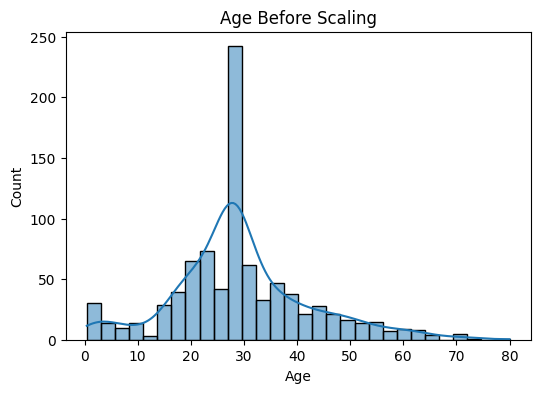

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], kde=True)
plt.title("Age Before Scaling")
plt.show()

In [11]:
scaler = StandardScaler()

standard_age = scaler.fit_transform(df[["Age"]])

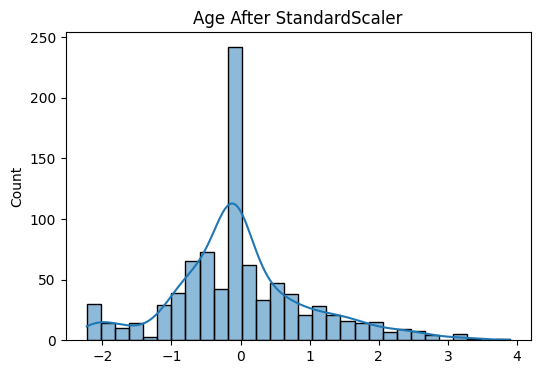

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(standard_age.flatten(), kde=True)
plt.title("Age After StandardScaler")
plt.show()

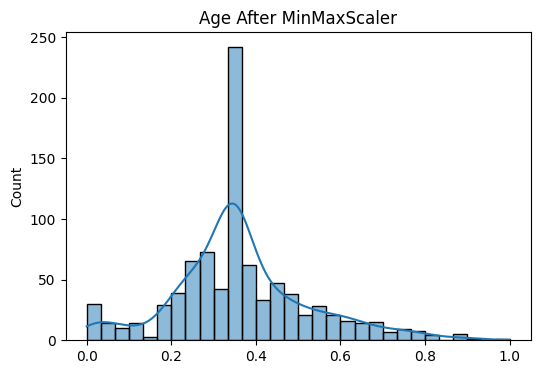

In [13]:
minmax = MinMaxScaler()

minmax_age = minmax.fit_transform(df[["Age"]])

plt.figure(figsize=(6,4))
sns.histplot(minmax_age.flatten(), kde=True)
plt.title("Age After MinMaxScaler")
plt.show()

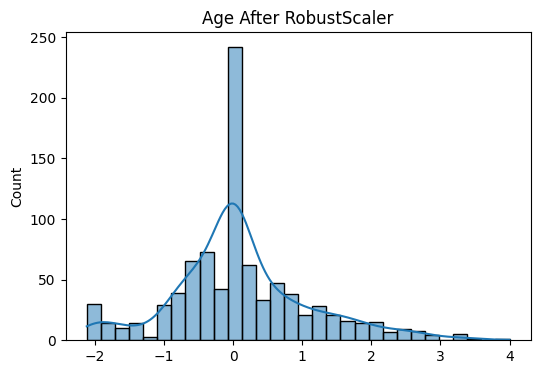

In [14]:
robust = RobustScaler()

robust_age = robust.fit_transform(df[["Age"]])

plt.figure(figsize=(6,4))
sns.histplot(robust_age.flatten(), kde=True)
plt.title("Age After RobustScaler")
plt.show()

In [15]:
feature_df = label_df.copy()

feature_df = feature_df.drop(columns=["Name","Ticket","Cabin"])

feature_df = pd.get_dummies(feature_df)

X = feature_df.drop("Survived", axis=1)

y = feature_df["Survived"]

In [16]:
selector = SelectKBest(score_func=f_classif, k=5)

selector.fit(X, y)

selected = X.columns[selector.get_support()]

print("Top 5 Features")

print(selected)

Top 5 Features
Index(['Pclass', 'Sex', 'Fare', 'Embarked_C', 'Embarked_S'], dtype='object')


In [17]:
assert not df.empty

assert len(selected) == 5

print("All Tests Passed")

All Tests Passed
